# 是时候获取SVF的直接计算方式了
有人做过一阶的https://cytomic.com/files/dsp/matched-svf1-ivanstov.pdf  
but二阶还没有

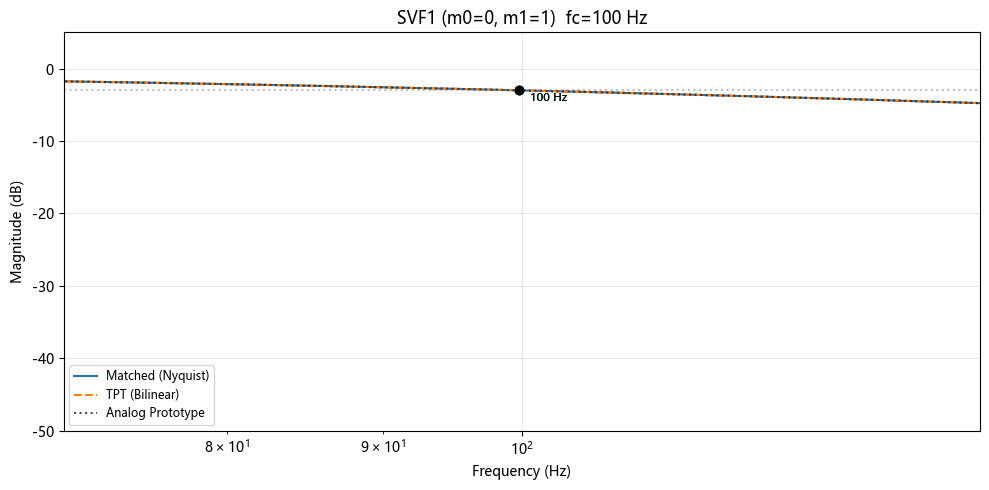

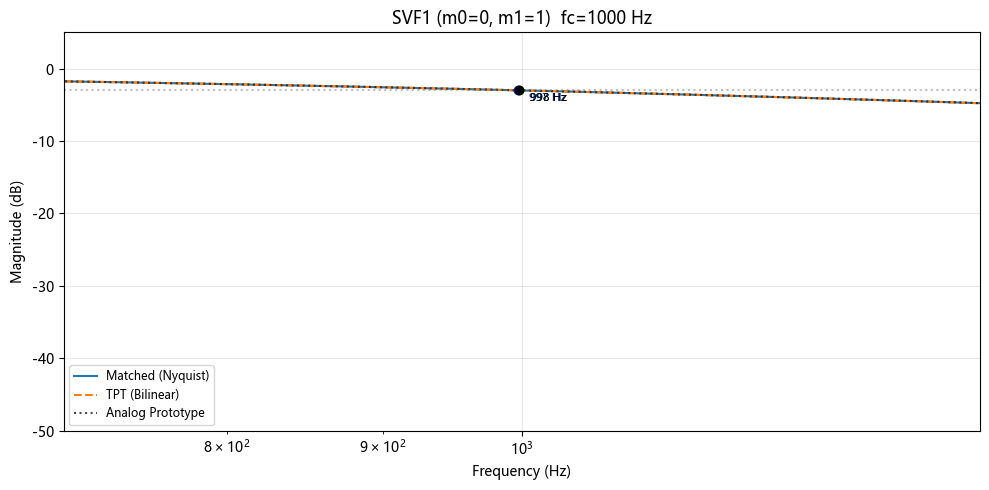

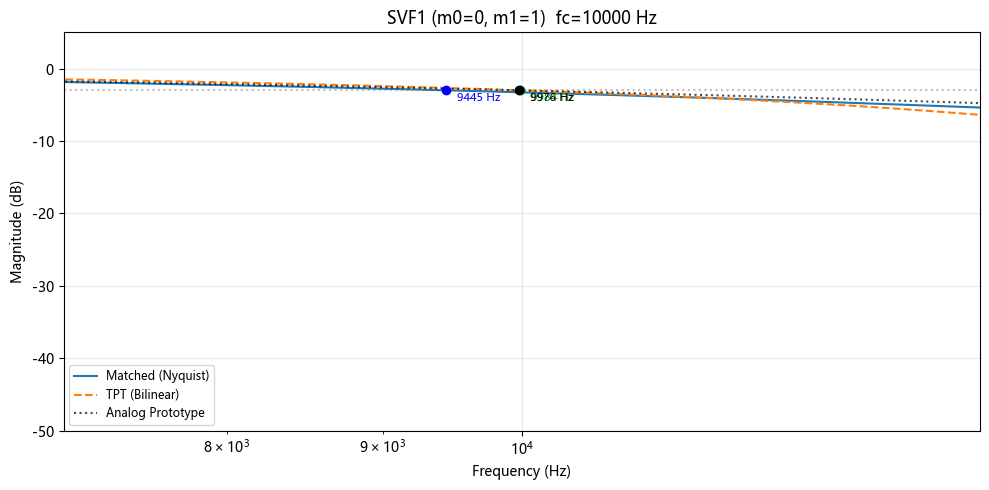

In [97]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy.signal as signal

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

def matched_svf1_response(fs, cutoff, m0, m1, t=2.0, nfft=4096):
    """
    Nyquist Matched SVF1 frequency response

    Parameters
    ----------
    fs : sample rate
    cutoff : Hz
    m0,m1 : mixing coefficients
    t : Ivantsov parameter
    """

    f = cutoff / fs

    gn = 1.0 / np.sqrt(1.0 + (f * t) ** 2)

    gz = np.pi * f * gn

    sign = 1.0 if m0 >= 0 else -1.0

    m0z = sign * np.sqrt(m0**2 + (m1 * f * t)**2) * gn
    m1z = m1

    w = np.linspace(0, np.pi, nfft)
    z = np.exp(-1j * w)

    H = (m0z + gz*m1z + (-m0z + gz*m1z)*z) / \
        (1 + gz + (gz - 1)*z)

    freq = w/(2*np.pi)*fs

    return freq, H

def tpt_svf1_response(fs, cutoff, m0, m1, nfft=4096):

    g = np.tan(np.pi * cutoff / fs)

    w = np.linspace(0, np.pi, nfft)
    z = np.exp(-1j*w)

    H = (m0 + g*m1 + (-m0 + g*m1)*z) / \
        (1 + g + (g-1)*z)

    freq = w/(2*np.pi)*fs

    return freq, H

def get_analog_coefficients(filter_type, fc, gain_db=10.0):
    wc = 2.0 * np.pi * fc; g = 10.0 ** (gain_db / 20.0)
    if filter_type.lower() in ["high pass", "hp"]:     return [1.0, 0.0], [1.0, wc]
    elif filter_type.lower() in ["low pass", "lp"]:    return [wc], [1.0, wc]
    elif filter_type.lower() in ["all pass", "ap"]:    return [1.0, -wc], [1.0, wc]
    elif filter_type.lower() in ["low shelf", "ls"]:   return [1.0, wc * np.sqrt(g)], [1.0, wc / np.sqrt(g)]
    elif filter_type.lower() in ["high shelf", "hs"]:  return [g, wc * np.sqrt(g)], [1.0, wc * np.sqrt(g)]
    else: raise ValueError(f"Unknown filter type: {filter_type}")

def make_fc_figure(fc, fs):
    freq, H1 = matched_svf1_response(fs, fc, 0, 1, t=2.0)
    _, H2 = tpt_svf1_response(fs, fc, 0, 1)

    # 模拟原型 (一阶低通)
    b_an, a_an = get_analog_coefficients("low pass", fc)
    _, H_an = signal.freqs(b_an, a_an, worN=freq * 2 * np.pi)

    mag1 = 20 * np.log10(np.maximum(np.abs(H1), 1e-15))
    mag2 = 20 * np.log10(np.maximum(np.abs(H2), 1e-15))
    mag_an = 20 * np.log10(np.maximum(np.abs(H_an), 1e-15))

    plt.figure(figsize=(10, 5))
    plt.semilogx(freq, mag1, label="Matched (Nyquist)")
    plt.semilogx(freq, mag2, "--", label="TPT (Bilinear)")
    plt.semilogx(freq, mag_an, ":", label="Analog Prototype", color="black", alpha=0.7)

    # 标记 -3dB 线
    plt.axhline(-3, color='gray', linestyle=':', alpha=0.5)
    for mag, name, c in [(mag1, 'Matched', 'blue'), (mag2, 'TPT', 'green'), (mag_an, 'Analog', 'black')]:
        idx = np.argmax(mag <= -3)
        if idx > 0 and mag[0] > -3:
            f3 = freq[idx-1] + (freq[idx] - freq[idx-1]) * (-3 - mag[idx-1]) / (mag[idx] - mag[idx-1])
            plt.plot(f3, -3, 'o', color=c, markersize=6)
            plt.annotate(f'{f3:.0f} Hz', (f3, -3), textcoords="offset points",
                        xytext=(8, -8), fontsize=8, color=c)

    plt.grid(True, alpha=0.3)
    plt.xlim(fc / 2**0.5, fc * 2**0.5)
    plt.ylim(-50, 5)
    plt.legend(fontsize='small')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"SVF1 (m0=0, m1=1)  fc={fc} Hz")
    plt.tight_layout()
    plt.show()

fs = 44100

make_fc_figure(100, fs)
make_fc_figure(1000, fs)
make_fc_figure(10000, fs)

看起来文章中的频率没有精确匹配，这下不得不自己推导了  
先试下用prewarp

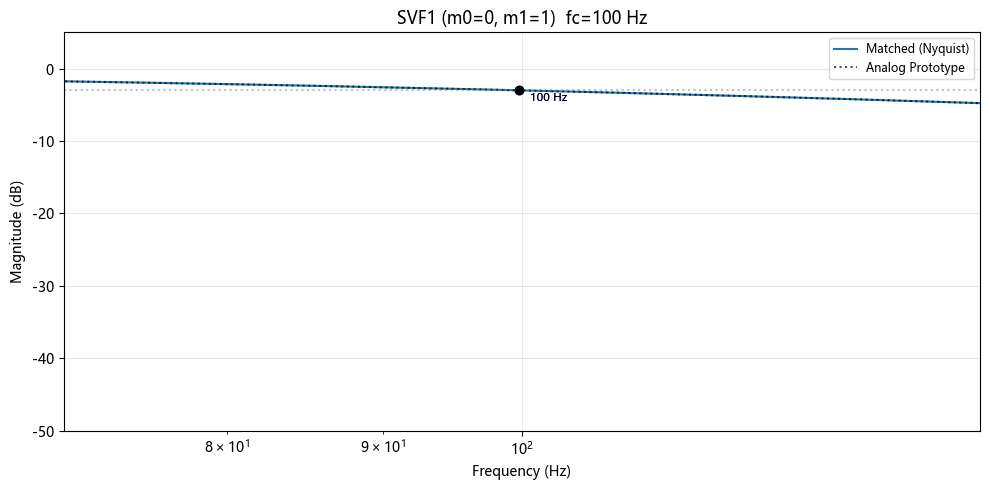

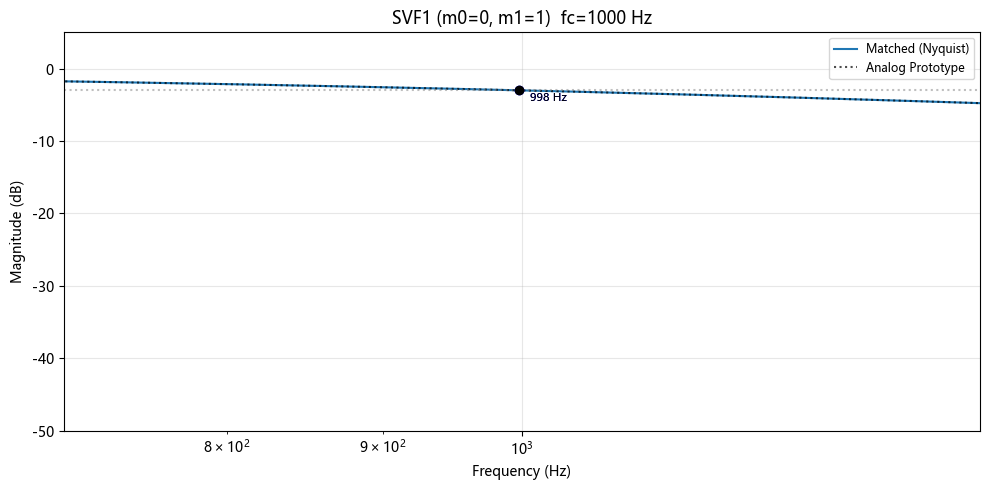

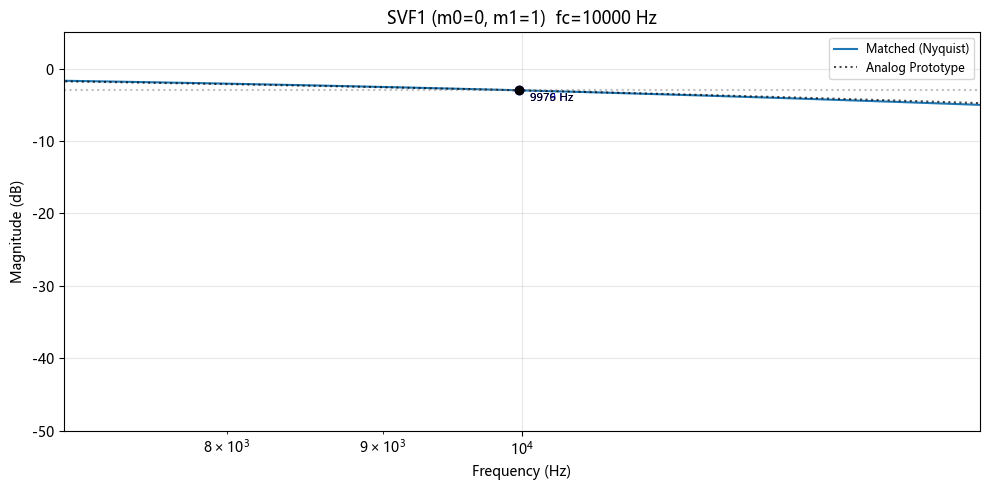

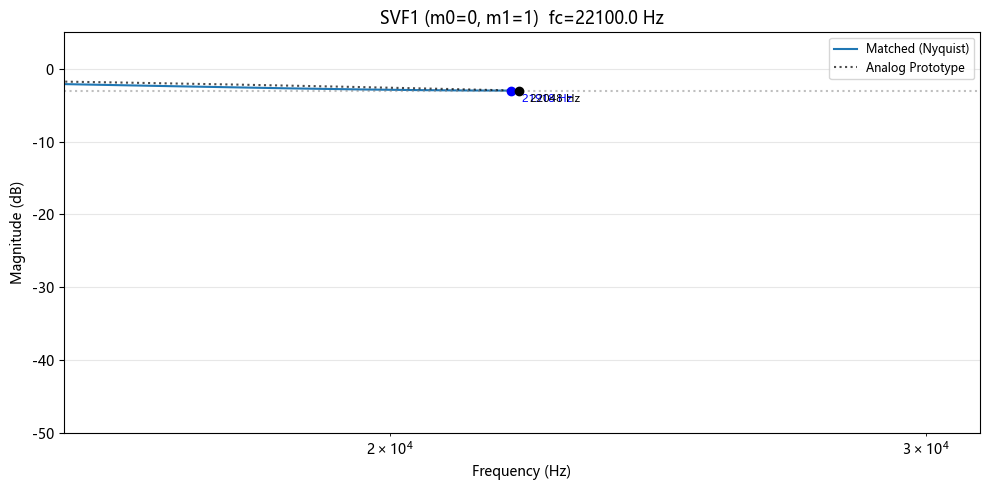

In [98]:
def get_prewarped_omega(fc, fs, sigma):
    if fc > fs / 2:
        return fs / fc
    omega_raw = fs / fc
    ctg_val = 1.0 / np.tan(np.pi / omega_raw)
    denom = np.sqrt(sigma**2 + (np.pi * ctg_val)**2)
    return denom

def matched_svf1_response(fs, cutoff, m0, m1, t=2.0, nfft=4096):
    """
    Nyquist Matched SVF1 frequency response

    Parameters
    ----------
    fs : sample rate
    cutoff : Hz
    m0,m1 : mixing coefficients
    t : Ivantsov parameter
    """

    f = 1 / get_prewarped_omega(cutoff, fs, t)

    gn = 1.0 / np.sqrt(1.0 + (f * t) ** 2)

    gz = np.pi * f * gn

    sign = 1.0 if m0 >= 0 else -1.0

    m0z = sign * np.sqrt(m0**2 + (m1 * f * t)**2) * gn
    m1z = m1

    w = np.linspace(0, np.pi, nfft)
    z = np.exp(-1j * w)

    H = (m0z + gz*m1z + (-m0z + gz*m1z)*z) / \
        (1 + gz + (gz - 1)*z)

    freq = w/(2*np.pi)*fs

    return freq, H

def make_fc_figure(fc, fs):
    freq, H1 = matched_svf1_response(fs, fc, 0, 1, t=2.0)

    # 模拟原型 (一阶低通)
    b_an, a_an = get_analog_coefficients("low pass", fc)
    _, H_an = signal.freqs(b_an, a_an, worN=freq * 2 * np.pi)

    mag1 = 20 * np.log10(np.maximum(np.abs(H1), 1e-15))
    mag_an = 20 * np.log10(np.maximum(np.abs(H_an), 1e-15))

    plt.figure(figsize=(10, 5))
    plt.semilogx(freq, mag1, label="Matched (Nyquist)")
    plt.semilogx(freq, mag_an, ":", label="Analog Prototype", color="black", alpha=0.7)

    # 标记 -3dB 线
    plt.axhline(-3, color='gray', linestyle=':', alpha=0.5)
    for mag, name, c in [(mag1, 'Matched', 'blue'), (mag_an, 'Analog', 'black')]:
        idx = np.argmax(mag <= -3)
        if idx > 0 and mag[0] > -3:
            f3 = freq[idx-1] + (freq[idx] - freq[idx-1]) * (-3 - mag[idx-1]) / (mag[idx] - mag[idx-1])
            plt.plot(f3, -3, 'o', color=c, markersize=6)
            plt.annotate(f'{f3:.0f} Hz', (f3, -3), textcoords="offset points",
                        xytext=(8, -8), fontsize=8, color=c)

    plt.grid(True, alpha=0.3)
    plt.xlim(fc / 2**0.5, fc * 2**0.5)
    plt.ylim(-50, 5)
    plt.legend(fontsize='small')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"SVF1 (m0=0, m1=1)  fc={fc} Hz")
    plt.tight_layout()
    plt.show()

fs = 44100
make_fc_figure(100, fs)
make_fc_figure(1000, fs)
make_fc_figure(10000, fs)
make_fc_figure(fs/2 + 50, fs)

# review TPT-SVF
tpt-svf的传递函数应该是`H(z) = (m0+g*m1+(g*m1-m0)*z^-1)/(1+g+(g-1)*z^-1)`  
其中使用双线性变换设计时`g = tan(pi * fc / fs)`  

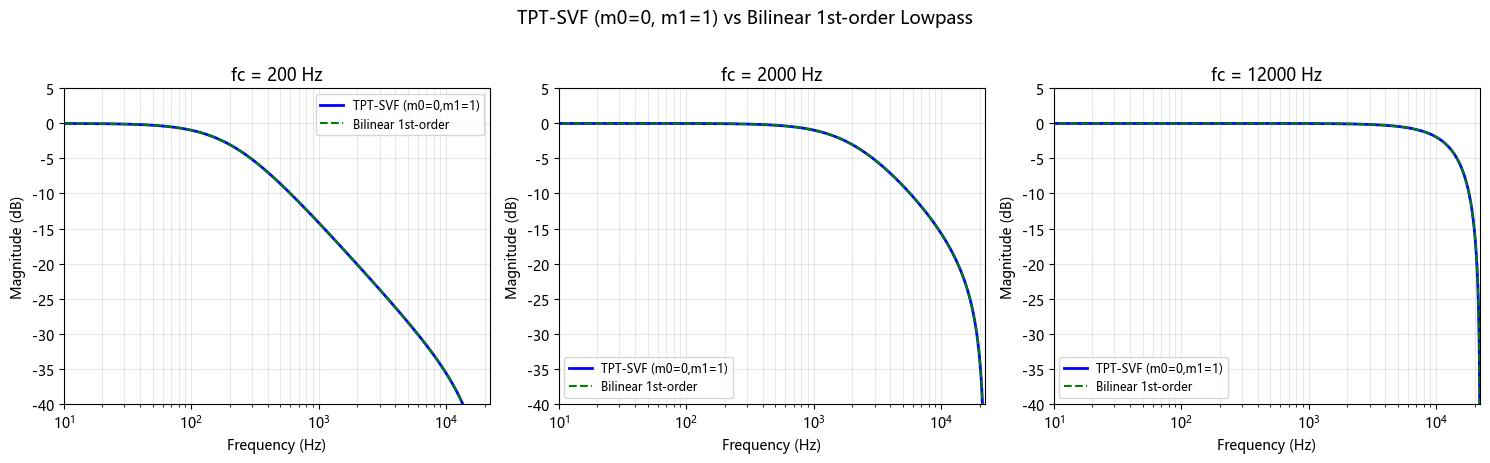

In [99]:
def get_bilinear_first_order_coefficients(filter_type, fc, fs, gain_db=10.0):
    Omega_c = 2.0 * np.pi * fc
    Omega_warped = 2.0 * fs * np.tan(Omega_c / (2.0 * fs))
    A = 10.0 ** (gain_db / 20.0)
    t = filter_type.lower()
    if t in ["low pass", "lp"]:
        d = 2.0 * fs + Omega_warped; return [Omega_warped / d, Omega_warped / d], [1.0, (Omega_warped - 2.0 * fs) / d]
    elif t in ["high pass", "hp"]:
        d = 2.0 * fs + Omega_warped; return [2.0 * fs / d, -2.0 * fs / d], [1.0, (Omega_warped - 2.0 * fs) / d]
    elif t in ["all pass", "ap"]:
        d = 2.0 * fs + Omega_warped; return [(Omega_warped - 2.0 * fs) / d, (Omega_warped + 2.0 * fs) / d], [1.0, (Omega_warped - 2.0 * fs) / d]
    elif t in ["low shelf", "ls"]:
        sA = np.sqrt(A); d = 2.0 * fs + Omega_warped / sA
        return [(2.0 * fs + A * Omega_warped / sA) / d, (-2.0 * fs + A * Omega_warped / sA) / d], [1.0, (-2.0 * fs + Omega_warped / sA) / d]
    elif t in ["high shelf", "hs"]:
        sA = np.sqrt(A); d = 2.0 * fs + sA * Omega_warped
        return [(2.0 * fs * A + sA * Omega_warped) / d, (-2.0 * fs * A + sA * Omega_warped) / d], [1.0, (-2.0 * fs + sA * Omega_warped) / d]
    else: raise ValueError(f"Unknown filter type: {filter_type}")

# ==========================================
# TPT-SVF (m0=0, m1=1) vs Bilinear
# ==========================================
# H(z) = (m0 + g*m1 + (g*m1 - m0)*z^-1) / (1 + g + (g - 1)*z^-1)
# g = tan(pi * fc / fs)
# m0=0, m1=1 -> H(z) = g*(1 + z^-1) / (1 + g + (g - 1)*z^-1)

fs = 44100.0
fc_list = [200, 2000, 12000]

fig, axes = plt.subplots(1, len(fc_list), figsize=(5 * len(fc_list), 4.5))

for col, fc in enumerate(fc_list):
    ax = axes[col]
    g_svf = np.tan(np.pi * fc / fs)
    b_svf = [g_svf / (1 + g_svf), g_svf / (1 + g_svf)]
    a_svf = [1.0, (g_svf - 1) / (1 + g_svf)]
    b_bl, a_bl = get_bilinear_first_order_coefficients("low pass", fc, fs)
    w, h_svf = signal.freqz(b_svf, a_svf, worN=2048, fs=fs)
    _, h_bl = signal.freqz(b_bl, a_bl, worN=2048, fs=fs)
    ax.plot(w, 20 * np.log10(np.maximum(np.abs(h_svf), 1e-5)),
            'b-', label='TPT-SVF (m0=0,m1=1)', linewidth=2)
    ax.plot(w, 20 * np.log10(np.maximum(np.abs(h_bl), 1e-5)),
            'g--', label='Bilinear 1st-order', linewidth=1.5)
    ax.set_xscale('log')
    ax.set_xlim(10, fs/2)
    ax.set_ylim(-40, 5)
    ax.set_title(f'fc = {fc} Hz')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize='small')

fig.suptitle('TPT-SVF (m0=0, m1=1) vs Bilinear 1st-order Lowpass', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 如何得到文章中的表达式
chatgpt数学似乎比哈基米强一点，这里是和chatgpt的讨论  
https://chatgpt.com/share/6a41f795-f508-83ee-a9c0-fcc19da95502  

等一下，我认为我需要认真推导一下，因为在二阶分子部分卡壳了  
首先写出一阶数字SVF的传递函数  

In [100]:
# 保留内置变量和模块
builtins = set(dir(__builtins__)) | {'np', 'sp', 'plt', 'signal'}
for var in list(globals().keys()):
    if var[0] != '_' and var not in builtins:
        del globals()[var]

import sympy as sp
from IPython.display import display

# 1. 定义符号（数字域加 d_ 前缀）
z = sp.symbols('z')
g = sp.symbols('g', positive=True)
d_m0, d_m1 = sp.symbols('m_0z m_1z', real=True)

# 2. 建立一阶数字 TPT 的拓扑代数方程
X, Vhp, Vlp, s1 = sp.symbols('X V_hp V_lp s_1')
eq_s1 = sp.Eq(s1, z**-1 * (Vlp + g * Vhp))
eq_vhp = sp.Eq(Vhp, X - (g * Vhp + s1))
eq_vlp = sp.Eq(Vlp, g * Vhp + s1)

# 3. 求解节点
solutions = sp.solve([eq_s1, eq_vhp, eq_vlp], (Vhp, Vlp, s1))

# 4. 根据新需求组合输出: d_m0 为 HP, d_m1 为 LP
Y_new = d_m0 * solutions[Vhp] + d_m1 * solutions[Vlp]

# 5. 计算并按照 z 整理传递函数 H(z)
H_z_new = sp.simplify(Y_new / X)
num, den = sp.fraction(H_z_new)
H_z_final = sp.collect(num, z) / sp.collect(den, z)

# --- Jupyter 渲染输出 ---
display(H_z_final)

(g*m_1z*(z + 1) + m_0z*(z - 1))/(g + z*(g + 1) - 1)

## 求分母
把分母部分转换为1+az^-1的部分，这样我们可以套用论文中的一阶部分极点表达式  

In [101]:
import sympy as sp
from IPython.display import display

# 符号定义
w, sigma = sp.symbols('w σ', positive=True, real=True)

# ---- SVF的积分器增益 gz ----
gz = sp.pi / sp.sqrt(w * w + sigma * sigma)
print('gz =')
display(gz)

# ---- phi(w) = (gz - 1) / (gz + 1) ----
phi = (gz - 1) / (gz + 1)
print('phi(w) = (gz - 1) / (gz + 1) =')
display(sp.simplify(phi))
# 即 phi(w) = (pi - sqrt(w^2 + sigma^2)) / (pi + sqrt(w^2 + sigma^2))

gz =


pi/sqrt(w**2 + σ**2)

phi(w) = (gz - 1) / (gz + 1) =


(pi - sqrt(w**2 + σ**2))/(sqrt(w**2 + σ**2) + pi)

## 求分子
首先写出一阶SVF的连续域功率函数和数字域功率函数  

In [102]:
import sympy as sp
from IPython.display import display

# 1. 定义符号
# w是模拟角频率，g是模拟截止角频率
# m0 是高通(HP)混合，m1 是低通(LP)混合
a_w, a_g = sp.symbols('omega g', positive=True)
a_m0, a_m1 = sp.symbols('m_0 m_1', real=True)

# 2. 定义一阶复数域传递函数 H(s)
# H(s) = (m0*s + m1*g) / (s + g)
#   m0*s 项 → 高频主导 → HP
#   m1*g 项 → 低频主导 → LP
a_s = sp.symbols('s')
a_H_s = (a_m0*a_s + a_m1*a_g) / (a_s + a_g)

# 3. 代入 s = jω 求模平方
a_H_jw = a_H_s.subs(a_s, sp.I * a_w)
a_H_svf1_sqr_power = sp.simplify(a_H_jw * sp.conjugate(a_H_jw))

# 4. 漂亮输出
print("一阶系统通用的幅度平方表达式 |H(jω)|² :")
display(a_H_svf1_sqr_power)

一阶系统通用的幅度平方表达式 |H(jω)|² :


(g**2*m_1**2 + m_0**2*omega**2)/(g**2 + omega**2)

In [103]:
# 先匹配高通
display(a_H_svf1_sqr_power.subs(a_w, 0))
display(H_z_final.subs(z, 1)**2)
# 因此m1z = m1

m_1**2

m_1z**2

In [104]:
# 再匹配低通
# 设模拟域在 ω = fs/σ 与数字域在 Ω = π 处功率响应相等
# 由此解出 m0z (d_m0)

fs, iv_w, sigma = sp.symbols('fs w_0 σ')
expr_an = a_H_svf1_sqr_power.subs({a_w: 2*sp.pi*(fs/sigma), a_g: 2*sp.pi*(fs/iv_w)})
expr_dg = H_z_final.subs({z: -1})**2

print("模拟 |H(j·fs/σ)|² :")
display(expr_an)
print("数字 |H(e^{jπ})|² :")
display(expr_dg)

# 求解 m0z(记得匹配m0的正负号)
sol_m0z = sp.solve(sp.Eq(expr_an, expr_dg), d_m0)
print("m0z =")
display(sp.simplify(sol_m0z[0]))

模拟 |H(j·fs/σ)|² :


(4*pi**2*fs**2*m_0**2/σ**2 + 4*pi**2*fs**2*m_1**2/w_0**2)/(4*pi**2*fs**2/σ**2 + 4*pi**2*fs**2/w_0**2)

数字 |H(e^{jπ})|² :


m_0z**2

m0z =


-sqrt((m_0**2*w_0**2 + m_1**2*σ**2)/(w_0**2 + σ**2))

# 额外内容
使用论文4.1/4.2的方法尝试推导

In [105]:
# 保留内置变量和模块
builtins = set(dir(__builtins__)) | {'np', 'sp', 'plt', 'signal'}
for var in list(globals().keys()):
    if var[0] != '_' and var not in builtins:
        del globals()[var]

import sympy as sp
from IPython.display import display

# 1. 定义符号
# w是模拟角频率，g是模拟截止角频率
# m0 是高通(HP)混合，m1 是低通(LP)混合
a_w, a_g = sp.symbols('omega g', positive=True)
a_m0, a_m1 = sp.symbols('m_0 m_1', real=True)

# 2. 定义一阶复数域传递函数 H(s)
# H(s) = (m0*s + m1*g) / (s + g)
#   m0*s 项 → 高频主导 → HP
#   m1*g 项 → 低频主导 → LP
a_s = sp.symbols('s')
a_H_s = (a_m0*a_s + a_m1*a_g) / (a_s + a_g)

display(a_H_s)

(g*m_1 + m_0*s)/(g + s)

In [106]:
a_H_s = a_m1*a_g*(1+a_m0/(a_g*a_m1)*a_s)/(a_g*(1+a_s/a_g))
display(a_H_s)

c, c2, z = sp.symbols('c c2 z')
a_H_s = a_H_s.subs(1+a_m0*a_s/(a_g*a_m1), (1+c/z)/(1+c))
a_H_s = a_H_s.subs(1+a_s/a_g, (1+c2/z)/(1+c2))
display(sp.simplify(a_H_s))

print('c=')
display(a_m0/a_g/a_m1)

print('c2=')
display(1/a_g)

a, w, sigma = sp.symbols('a w σ')
print('phi(x)=')
phi = (sp.pi-c)/(sp.pi+c)
phi = phi.subs(c, sp.sqrt((w*a)**2 + sigma**2))
display(phi)

S = sp.simplify(
    a_H_s.subs({
        c2: phi.subs(a, 1/a_g),
        c: phi.subs(a, a_m0/a_g/a_m1)
    })
)
display(S)

print('数字svf下面有个')
display(a_g+z*(a_g+1)-1)
print('这怎么看都觉得gz=')
display(sp.pi*a_g/sp.sqrt(a_g*a_g*sigma*sigma+w*w))
print('but这个代入程序会得到错误结果，真是奇怪')

m_1*(1 + m_0*s/(g*m_1))/(1 + s/g)

m_1*(c + z)*(c2 + 1)/((c + 1)*(c2 + z))

c=


m_0/(g*m_1)

c2=


...

数字svf下面有个


g + z*(g + 1) - 1

这怎么看都觉得gz=


pi*g/sqrt(g**2*σ**2 + w**2)

but这个代入程序会得到错误结果，真是奇怪


In [107]:
import sympy as sp

# 1. 定义所有必要的符号
# g, m1, m0 为连续域模拟原型参数；w = fs/fc 为频率比；sigma 为去畸变自由参数
g, m1, m0, w, sigma, z = sp.symbols('g m1 m0 w sigma z', positive=True)

# 定义数字 SVF 待求的三个核心系数
gz, m0z, m1z = sp.symbols('gz m0z m1z', positive=True)

print("--- 步骤 1: 构建基于论文 4.1 节的一阶去畸变 H(z) ---")
# 根据归一化结果：
# x_den = w / g
# x_num = (w * m0) / (g * m1)
x_den = w / g
x_num = (w * m0) / (g * m1)

# 论文核心定义映射函数 phi(x) [cite: 38]
phi_den = (sp.pi - sp.sqrt(x_den**2 + sigma**2)) / (sp.pi + sp.sqrt(x_den**2 + sigma**2))
phi_num = (sp.pi - sp.sqrt(x_num**2 + sigma**2)) / (sp.pi + sp.sqrt(x_num**2 + sigma**2))

# 论文 4.1 映射形式：(as + 1) <-> (1 + c*z^-1) / (1 + c) [cite: 231]
# H(z) = m1 * [ (1 + c_num/z) / (1 + c_num) ] / [ (1 + c_den/z) / (1 + c_den) ]
H_decramped = m1 * ((1 + phi_num * z**-1) / (1 + phi_num)) / ((1 + phi_den * z**-1) / (1 + phi_den))
H_decramped = sp.simplify(H_decramped)

print("--- 步骤 2: 构建标准数字一阶 SVF 的 H(z) ---")
# 标准一阶 ZDF/TPT SVF 形式
H_svf = (gz * m1z * (z + 1) + m0z * (z - 1)) / (gz * (z + 1) + (z - 1))

print("--- 步骤 3: 提取关于 z 的多项式系数并进行全等匹配 ---")
# 分别提取两个有理分式的分子与分母多项式
num_dec, den_dec = sp.fraction(H_decramped)
num_svf, den_svf = sp.fraction(H_svf)

# 将两边分别写成关于 z 的多项式形式 (A*z + B)
num_dec_coeff = sp.collect(sp.expand(num_dec), z, evaluate=False)
den_dec_coeff = sp.collect(sp.expand(den_dec), z, evaluate=False)

num_svf_coeff = sp.collect(sp.expand(num_svf), z, evaluate=False)
den_svf_coeff = sp.collect(sp.expand(den_svf), z, evaluate=False)

# 有理分式全等条件：对应 z 的幂次系数成比例。
# 我们以分母常数项（z^0 的系数）的比值作为基准比例 ratio
ratio = den_dec_coeff[1] / den_svf_coeff[1]

# 建立方程组：分母z^1项、分子z^1项、分子z^0项 的比值必须都等于 ratio
equations = [
    sp.Eq(den_dec_coeff[z] / den_svf_coeff[z], ratio),
    sp.Eq(num_dec_coeff[z] / num_svf_coeff[z], ratio),
    sp.Eq(num_dec_coeff[1] / num_svf_coeff[1], ratio)
]

print("--- 步骤 4: 求解方程组 ---")
# 求解未知数 gz, m1z, m0z
sol = sp.solve(equations, (gz, m1z, m0z))

# 提取解（sol 是一个包含元组的列表）
res_gz, res_m1z, res_m0z = sol[0]

print("\n================== 求解结果 ==================\n")
# 使用 simplify 展开并精简代数式
print("gz  = ", sp.simplify(res_gz))
print("\nm1z = ", sp.simplify(res_m1z))
print("\nm0z = ", sp.simplify(res_m0z))
print("\n==============================================")


--- 步骤 1: 构建基于论文 4.1 节的一阶去畸变 H(z) ---
--- 步骤 2: 构建标准数字一阶 SVF 的 H(z) ---
--- 步骤 3: 提取关于 z 的多项式系数并进行全等匹配 ---
--- 步骤 4: 求解方程组 ---

================== 求解结果 ==================

gz  =  pi*g/sqrt(g**2*sigma**2 + w**2)

m1z =  m1

m0z =  (-pi*g + sqrt(g**2*sigma**2 + w**2))*sqrt(g**2*m1**2*sigma**2 + m0**2*w**2)/(g**2*sigma**2 - pi*g*sqrt(g**2*sigma**2 + w**2) + w**2)



## 总结

In [108]:
# 符号定义
# w是文章里的omega, t是σ, m0是高通混合，m1是低通混合
w, t, m0, m1 = sp.symbols('w σ m0 m1', positive=True, real=True)

# ---- SVF的积分器增益 gz ----
gz = sp.pi / sp.sqrt(w * w + t * t)
print('gz =')
display(gz)

# ---- 混合系数 m0z(HP) m1z(LP) (记得匹配m0的正负号) ----
m0z = sp.sqrt((m0*m0+t*t*m1*m1/w/w)/(1+t*t/w/w))
print('m0z =')
display(m0z)

# ---- 4. m1z = m1 (不变) ----
print('m1z = m1')

gz =


pi/sqrt(w**2 + σ**2)

m0z =


sqrt(m0**2 + m1**2*σ**2/w**2)/sqrt(1 + σ**2/w**2)

m1z = m1


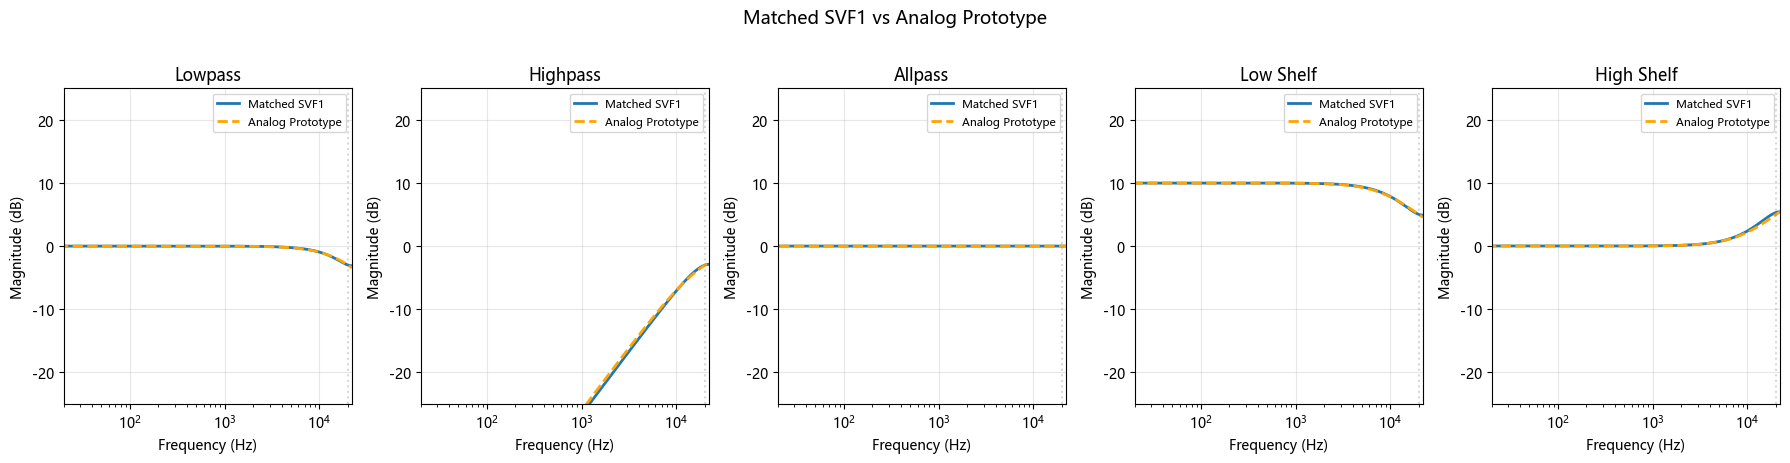

In [109]:
# ============================================================
# Matched SVF1 frequency response verification
# ============================================================

# 保留内置变量和模块
builtins = set(dir(__builtins__)) | {'np', 'sp', 'plt', 'signal'}
for var in list(globals().keys()):
    if var[0] != '_' and var not in builtins:
        del globals()[var]


import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def get_prewarped_omega(fc, fs, sigma):
    if fc > fs / 2:
        return fs / fc

    omega_raw = fs / fc
    ctg = 1.0 / np.tan(np.pi / omega_raw)
    return np.sqrt(sigma**2 + (np.pi * ctg)**2)


def get_analog_coefficients(filter_type, fc, gain_db=10.0):

    wc = 2 * np.pi * fc
    G = 10 ** (gain_db / 20)

    t = filter_type.lower()

    if t in ("low pass", "lp"):
        b = [wc]
        a = [1, wc]

    elif t in ("high pass", "hp"):
        b = [1, 0]
        a = [1, wc]

    elif t in ("all pass", "ap"):
        b = [1, -wc]
        a = [1, wc]

    elif t in ("low shelf", "ls"):
        b = [1, wc * np.sqrt(G)]
        a = [1, wc / np.sqrt(G)]

    elif t in ("high shelf", "hs"):
        b = [G, wc * np.sqrt(G)]
        a = [1, wc * np.sqrt(G)]

    else:
        raise ValueError(filter_type)

    return b, a


def matched_svf1_response(fs, cutoff, m0, m1, t=2.0, nfft=4096):

    w = get_prewarped_omega(cutoff, fs, t)

    gz = np.pi / np.sqrt(w*w + t*t)

    sign = 1 if m0 >= 0 else -1

    m0z = sign * np.sqrt(
        (m0*m0 + t*t*m1*m1/(w*w))
        /
        (1 + t*t/(w*w))
    )

    m1z = m1

    w = np.linspace(0, np.pi, nfft)
    z = np.exp(-1j*w)

    H = (
        m0z + gz*m1z + (-m0z + gz*m1z)*z
    ) / (
        1 + gz + (gz-1)*z
    )

    freq = w / (2*np.pi) * fs

    return freq, H


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

fs = 44100
fc = 20000
gain_db = 10

G = 10 ** (gain_db / 20)

filters = [

    # title        prototype      (m0,m1)      fc
    ("Lowpass",    "low pass",    (0, 1),      fc),
    ("Highpass",   "high pass",   (1, 0),      fc),
    ("Allpass",    "all pass",    (1,-1),      fc),

    ("Low Shelf",  "low shelf",   (1, G),      fc/np.sqrt(G)),
    ("High Shelf", "high shelf",  (G, 1),      fc*np.sqrt(G)),
]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, len(filters), figsize=(18,4.5))

for ax, (title, proto, mix, fc_use) in zip(axes, filters):

    m0, m1 = mix

    freq, H_svf = matched_svf1_response(
        fs,
        fc_use,
        m0,
        m1
    )

    b, a = get_analog_coefficients(
        proto,
        fc,
        gain_db
    )

    _, H_ref = signal.freqs(
        b,
        a,
        worN=2*np.pi*freq
    )

    ax.semilogx(
        freq,
        20*np.log10(np.maximum(np.abs(H_svf),1e-15)),
        lw=2,
        label="Matched SVF1"
    )

    ax.semilogx(
        freq,
        20*np.log10(np.maximum(np.abs(H_ref),1e-15)),
        "--",
        lw=2,
        color="orange",
        label="Analog Prototype"
    )

    ax.axvline(fc, color='gray', ls=':', alpha=.3)

    ax.set(
        xscale="log",
        xlim=(20, fs/2),
        ylim=(-25,25),
        xlabel="Frequency (Hz)",
        ylabel="Magnitude (dB)",
        title=title
    )

    ax.grid(alpha=.3)
    ax.legend(fontsize=8)

fig.suptitle(
    "Matched SVF1 vs Analog Prototype",
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.show()